# ECCT vs Mamba — BER & Inference Time Comparison
**LDPC Code** | Log-scale BER curves + inference time per codeword

In [1]:
import os
OUTPUT_DIR = 'plots/n3222_k166'
os.makedirs(OUTPUT_DIR, exist_ok=True)



In [2]:
# ── CONFIG — edit these paths ──────────────────────────────────────────────
ECCT_ALIST = 'transformer_ecct/Codes_DB/POLAR_N64_K48.txt'

ECCT_CHECKPOINT = 'ECCT/Results_ECCT/POLAR__Code_n_64_k_48__22_03_2026_22_36_01/best_model'
MAMBA_PATH      = 'results/run_5/DB8DD6598C02D4D5C69BA9EF528B588A'


CODE_N = 64
CODE_K = 48

TEST_BATCH_SIZE = 128
NUM_SAMPLES     = 10000   # codewords per EbN0 point

EBNO_RANGE = [4, 4.5, 5, 5.5, 6]

def sign_to_bin(x):
    return (1 - x) / 2

In [3]:
import os, sys, time, json
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from torch.utils.data import DataLoader

ROOT = os.path.abspath('.')                          # 5G-Polar/
ECCT_DIR = os.path.join(ROOT, 'ECCT')   # 5G-Polar/transformer_ecct/
for p in [ROOT, ECCT_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. Load ECCT

In [4]:
from ECCT.Model import ECC_Transformer
from ECCT.Codes import Get_Generator_and_Parity
import os


class Code():
    pass

ecct_code = Code()
ecct_code.k = CODE_K
ecct_code.n = CODE_N
ecct_code.code_type = 'POLAR'

os.chdir('ECCT')
G, H = Get_Generator_and_Parity(ecct_code, standard_form=False)
os.chdir('..') 

ecct_code.generator_matrix = torch.from_numpy(G).transpose(0, 1).long()
ecct_code.pc_matrix        = torch.from_numpy(H).long()

import argparse

ecct_args = argparse.Namespace(
    code=ecct_code,
    N_dec=8,
    d_model=64,
    h=8
)

ecct_model = ECC_Transformer(ecct_args, dropout=0).to(device)


#ecct_model = torch.load(ECCT_CHECKPOINT, weights_only=False, map_location=device)


ecct_model.eval()


ECC_Transformer(
  (decoder): Encoder(
    (layers): ModuleList(
      (0-7): 8 x EncoderLayer(
        (self_attn): MultiHeadedAttention(
          (linears): ModuleList(
            (0-3): 4 x Linear(in_features=64, out_features=64, bias=True)
          )
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (feed_forward): PositionwiseFeedForward(
          (w_1): Linear(in_features=64, out_features=256, bias=True)
          (w_2): Linear(in_features=256, out_features=64, bias=True)
          (dropout): Dropout(p=0, inplace=False)
        )
        (sublayer): ModuleList(
          (0-1): 2 x SublayerConnection(
            (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0, inplace=False)
          )
        )
      )
    )
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (oned_final_embed): Sequential(
    (0): Linear(in_features=64, o

## 2. Load Mamba

In [5]:
from initialization import initialize
from models.ECCM import ECCM_only_mamba


# mamba_config, mamba_model, *_ = initialize(
#     MAMBA_PATH, ECCM_only_mamba,
#     experiment=True, summary=False,
#     best=True, best_ber='BER_3'
# )

mamba_config, mamba_model, *_ = initialize(
    MAMBA_PATH, ECCM_only_mamba,
    experiment=True, summary=False,
    best=True
)
mamba_config.test_batch_size = TEST_BATCH_SIZE
mamba_model = mamba_model.to(device)
mamba_model.eval()
mamba_code = mamba_config.code

print(f"Mamba loaded — code n={mamba_code.n}, k={mamba_code.k}")

/home/anjal/Desktop/Code/mamba-seq-pred/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/anjal/Desktop/Code/mamba-seq-pred/venv/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/anjal/Desktop/Code/mamba-seq-pred/venv/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/anjal/Desktop/Code/mamba-seq-pred/venv/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._regis

using path results/run_5/DB8DD6598C02D4D5C69BA9EF528B588A
cuda
results/run_5/DB8DD6598C02D4D5C69BA9EF528B588A/8EFCC4E8D6DD2F59B21179BF060BCFD4
Mamba loaded — code n=64, k=48


## 3. Inference helper

In [6]:
from dataset import ECC_Dataset, BER as calc_BER, FER as calc_FER, EbN0_to_std
import torch.nn.functional as F

def sign_to_bin(x):
    return 0.5 * (1 - x)

def bin_to_sign(x):
    return 1 - 2 * x

In [7]:
def run_inference_mamba(model, code, EbN0_list, batch_size, num_samples, device, is_ecct):
    import torch
    from dataset import ECC_Dataset, BER as calc_BER, FER as calc_FER, EbN0_to_std, bin_to_sign
    from torch.utils.data import DataLoader
    import time

    rate = code.k / code.n
    results = {}
    model.eval()

    for EbN0 in EbN0_list:
        std = EbN0_to_std(EbN0, rate)
        dataset = ECC_Dataset(code, [std], len=num_samples, zero_cw=False)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)

        total_ber = total_fer = cum_count = total_time = 0.0

        with torch.no_grad():
            for m, x, z_noise, y, magnitude, syndrome in loader:

                magnitude = magnitude.to(device)
                syndrome  = syndrome.to(device)
                x_dev     = x.to(device)
                y_dev     = y.to(device)

                # Needed only for ECCT
                if is_ecct:
                    z_mul = (y_dev * bin_to_sign(x_dev))

                # ---- timing start ----
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t0 = time.perf_counter()

                # ---- forward ----
                z_pred = model(magnitude, syndrome)

                if is_ecct:
                    # ✅ Proper ECCT path (use original loss function)
                    loss, x_pred = model.loss(-z_pred, z_mul, y_dev)
                else:
                    # ✅ Mamba / normal decoding
                    x_pred = model.get_codeword(z_pred, y_dev)

                # ---- timing end ----
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t1 = time.perf_counter()

                bs = x.shape[0]

                total_ber += calc_BER(x_pred, x_dev) * bs
                total_fer += calc_FER(x_pred, x_dev) * bs
                cum_count += bs
                total_time += (t1 - t0)

        # ---- metrics ----
        ber  = float(total_ber / cum_count)
        fer  = float(total_fer / cum_count)
        t_us = (total_time / cum_count) * 1e6

        results[EbN0] = {
            'ber': ber,
            'fer': fer,
            'time_us': t_us
        }

        mode = "ECCT" if is_ecct else "Mamba"
        print(f'[{mode}] EbN0={EbN0:.1f} | BER={ber:.3e} | FER={fer:.3e} | {t_us:.2f} µs/cw')

    return results

## 4. Run inference

In [8]:
# print('\n=== Mamba ===')
# mamba_results = run_inference_mamba(
#     mamba_model, mamba_code, EBNO_RANGE,
#     TEST_BATCH_SIZE, NUM_SAMPLES, device, label='Mamba', is_ecct=False
# )
print('\n=== Mamba ===')
mamba_results = run_inference_mamba(
    mamba_model, mamba_code, EBNO_RANGE,
    TEST_BATCH_SIZE, NUM_SAMPLES, device, is_ecct=False
)

print('=== ECCT ===')
ecct_results = run_inference_mamba(
    ecct_model, ecct_code, EBNO_RANGE,
    TEST_BATCH_SIZE, NUM_SAMPLES, device, is_ecct=True
)



=== Mamba ===
[Mamba] EbN0=4.0 | BER=3.416e-03 | FER=9.710e-02 | 141.51 µs/cw
[Mamba] EbN0=4.5 | BER=1.523e-03 | FER=4.960e-02 | 113.98 µs/cw
[Mamba] EbN0=5.0 | BER=5.922e-04 | FER=1.880e-02 | 114.05 µs/cw
[Mamba] EbN0=5.5 | BER=2.359e-04 | FER=8.100e-03 | 114.10 µs/cw
[Mamba] EbN0=6.0 | BER=8.906e-05 | FER=2.900e-03 | 113.69 µs/cw
=== ECCT ===
[ECCT] EbN0=4.0 | BER=4.003e-01 | FER=1.000e+00 | 133.67 µs/cw
[ECCT] EbN0=4.5 | BER=3.990e-01 | FER=1.000e+00 | 131.90 µs/cw
[ECCT] EbN0=5.0 | BER=3.976e-01 | FER=1.000e+00 | 131.87 µs/cw
[ECCT] EbN0=5.5 | BER=3.958e-01 | FER=1.000e+00 | 132.07 µs/cw


KeyboardInterrupt: 

In [ ]:
# Quick debug — check one batch
for m, x, z, y, magnitude, syndrome in DataLoader(
        ECC_Dataset(ecct_code, [EbN0_to_std(4.0, CODE_K/CODE_N)], len=128, zero_cw=False),
        batch_size=128):
    with torch.no_grad():
        out = ecct_model(magnitude.to(device), syndrome.to(device))
    print("output shape:", out.shape)
    print("output range:", out.min().item(), out.max().item())
    print("output sample:", out[0, :8])
    print("x (codeword):", x[0, :8])
    print("z (error)   :", z[0, :8])
    print("y (received):", y[0, :8])
    break

output shape: torch.Size([128, 64])
output range: -2.873230218887329 4.260773181915283
output sample: tensor([ 0.2104, -1.5699, -0.7624,  2.2159,  1.4346, -2.0687, -1.6939,  0.8275],
       device='cuda:0')
x (codeword): tensor([0., 1., 0., 1., 1., 0., 1., 1.])
z (error)   : tensor([ 0.0591, -0.3784,  0.2707, -0.0965, -0.0073, -1.0105,  0.2087, -0.5092])
y (received): tensor([ 1.0591, -1.3784,  1.2707, -1.0965, -1.0073, -0.0105, -0.7913, -1.5092])


## 5. Summary table

In [ ]:
print(f"{'EbN0':>6} | {'ECCT BER':>12} | {'Mamba BER':>12} | {'ECCT µs':>10} | {'Mamba µs':>10}")
print('-' * 62)
for e in EBNO_RANGE:
    print(f"{e:>6.1f} | {ecct_results[e]['ber']:>12.3e} | {mamba_results[e]['ber']:>12.3e} | "
          f"{ecct_results[e]['time_us']:>10.2f} | {mamba_results[e]['time_us']:>10.2f}")

  EbN0 |     ECCT BER |    Mamba BER |    ECCT µs |   Mamba µs
--------------------------------------------------------------
   4.0 |    4.658e-01 |    3.733e-03 |     131.02 |     118.06
   4.5 |    4.679e-01 |    1.659e-03 |     131.29 |     115.11
   5.0 |    4.698e-01 |    6.750e-04 |     131.43 |     115.18
   5.5 |    4.724e-01 |    1.937e-04 |     131.64 |     114.32
   6.0 |    4.752e-01 |    5.781e-05 |     131.57 |     112.88


## 6. BER curve (log scale)

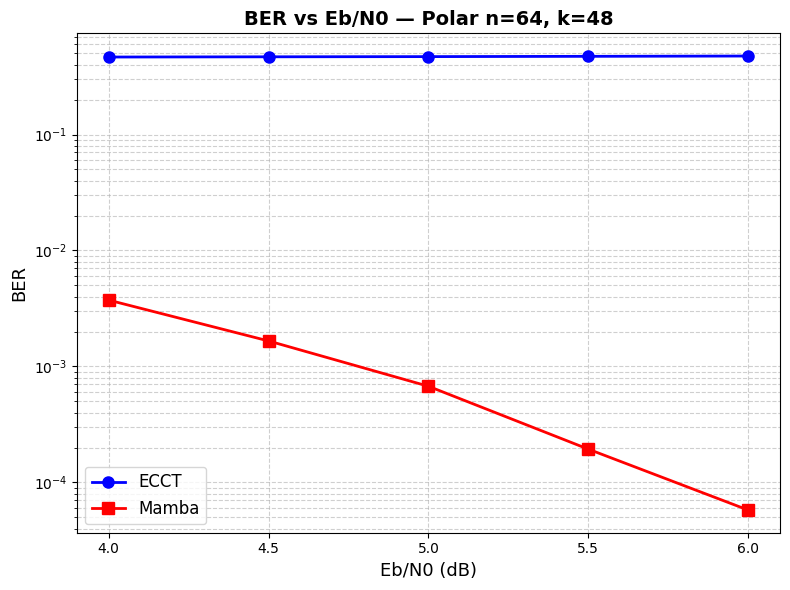

In [ ]:
ecct_ber  = [ecct_results[e]['ber']  for e in EBNO_RANGE]
mamba_ber = [mamba_results[e]['ber'] for e in EBNO_RANGE]
ecct_time  = [ecct_results[e]['time_us']  for e in EBNO_RANGE]
mamba_time = [mamba_results[e]['time_us'] for e in EBNO_RANGE]

# ── BER curve ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.semilogy(EBNO_RANGE, ecct_ber,  'b-o', linewidth=2, markersize=8, label='ECCT')
ax.semilogy(EBNO_RANGE, mamba_ber, 'r-s', linewidth=2, markersize=8, label='Mamba')
ax.set_xlabel('Eb/N0 (dB)', fontsize=13)
ax.set_ylabel('BER', fontsize=13)
ax.set_title(f'BER vs Eb/N0 — Polar n={CODE_N}, k={CODE_K}', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.set_xticks(EBNO_RANGE)
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ber_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Inference time comparison

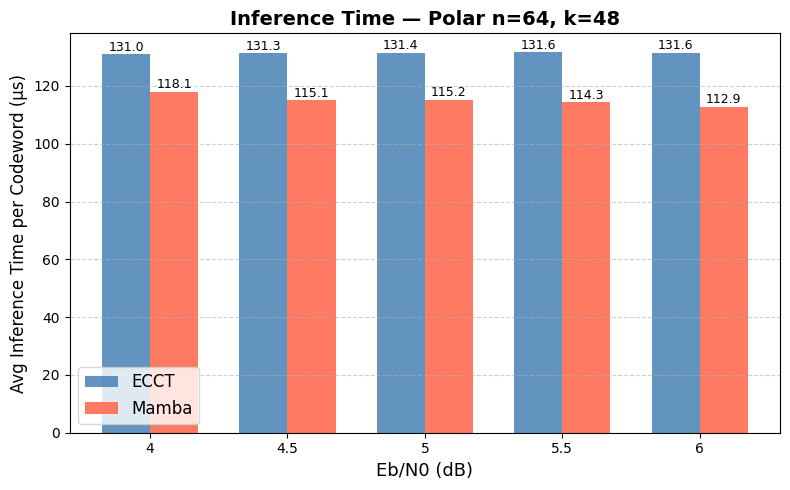

In [ ]:
x_idx = np.arange(len(EBNO_RANGE))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x_idx - width/2, ecct_time,  width, label='ECCT',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x_idx + width/2, mamba_time, width, label='Mamba', color='tomato',    alpha=0.85)
ax.set_xlabel('Eb/N0 (dB)', fontsize=13)
ax.set_ylabel('Avg Inference Time per Codeword (µs)', fontsize=12)
ax.set_title(f'Inference Time — Polar n={CODE_N}, k={CODE_K}', fontsize=14, fontweight='bold')
ax.set_xticks(x_idx)
ax.set_xticklabels([str(e) for e in EBNO_RANGE])
ax.legend(fontsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'inference_time.png'), dpi=150, bbox_inches='tight')
plt.show()


## 8. Combined figure (publication ready)

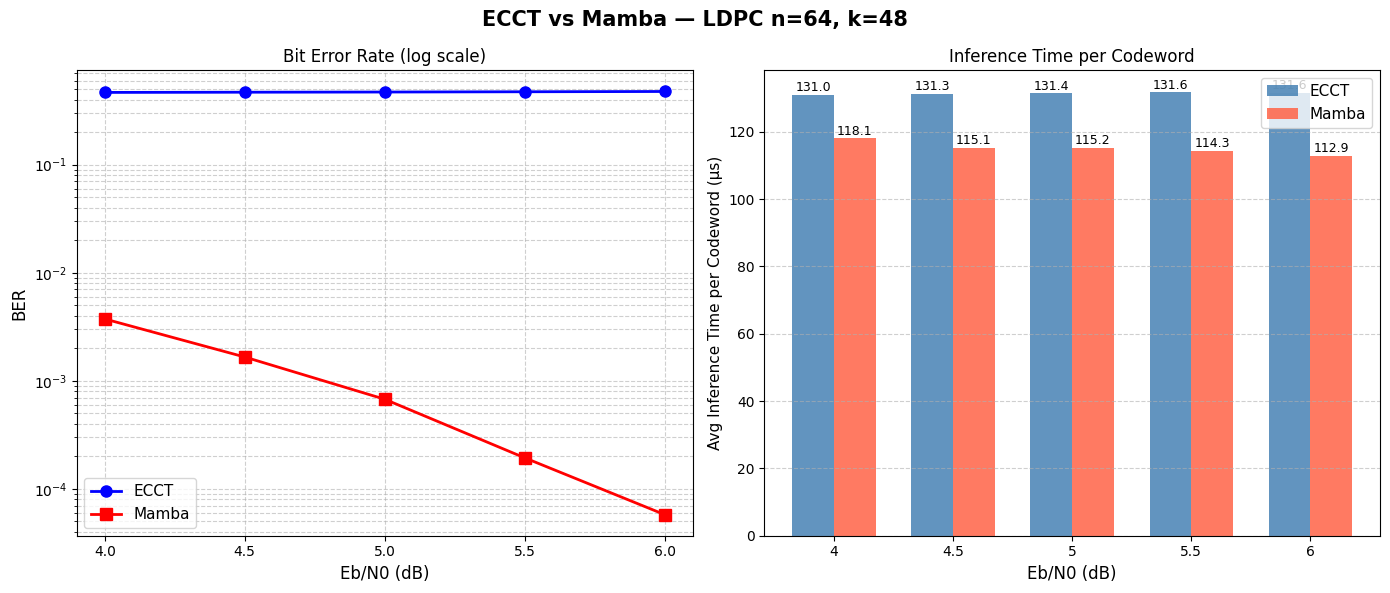

All plots saved to: /home/anjal/Desktop/Code/1978_Hybrid_Mamba_Transformer__Supplementary Material/plots/n3222_k166


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'ECCT vs Mamba — LDPC n={CODE_N}, k={CODE_K}', fontsize=15, fontweight='bold')
ax = axes[0]
ax.semilogy(EBNO_RANGE, ecct_ber,  'b-o', linewidth=2, markersize=8, label='ECCT')
ax.semilogy(EBNO_RANGE, mamba_ber, 'r-s', linewidth=2, markersize=8, label='Mamba')
ax.set_xlabel('Eb/N0 (dB)', fontsize=12)
ax.set_ylabel('BER', fontsize=12)
ax.set_title('Bit Error Rate (log scale)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.set_xticks(EBNO_RANGE)
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax2 = axes[1]
b1 = ax2.bar(x_idx - width/2, ecct_time,  width, label='ECCT',  color='steelblue', alpha=0.85)
b2 = ax2.bar(x_idx + width/2, mamba_time, width, label='Mamba', color='tomato',    alpha=0.85)
ax2.set_xlabel('Eb/N0 (dB)', fontsize=12)
ax2.set_ylabel('Avg Inference Time per Codeword (µs)', fontsize=11)
ax2.set_title('Inference Time per Codeword', fontsize=12)
ax2.set_xticks(x_idx)
ax2.set_xticklabels([str(e) for e in EBNO_RANGE])
ax2.legend(fontsize=11)
ax2.grid(True, axis='y', linestyle='--', alpha=0.6)
for bar in b1:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in b2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_combined.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'All plots saved to: {os.path.abspath(OUTPUT_DIR)}')

## 9. Save results to JSON

In [ ]:
all_results = {
    'code_n': CODE_N, 'code_k': CODE_K,
    'EbN0_range': EBNO_RANGE,
    'ecct':  ecct_results,
    'mamba': mamba_results
}
with open('ber_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print('Saved: ber_results.json')

Saved: ber_results.json
